In [ ]:
# %% Required Imports
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import zipfile,os
from google.colab import drive


# %% Step 1: Data Preprocessing
# Preprocess single-channel grayscale images
data_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # Ensure single-channel
    transforms.Resize((224, 224)),  # ResNet-50 input size
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])  # Normalize grayscale values
])

drive.mount('/content/MyDrive')

zip_path = "/content/drive/MyDrive/combined_dataset.zip"
if not os.path.exists(zip_path):
  with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/drive/MyDrive/combined_dataset')

# Load dataset
data_dir = "combined_dataset"  # Replace with your dataset path
full_dataset = ImageFolder(data_dir, transform=data_transform)

# Split dataset into train/validation/test
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

# Data loaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

dataloaders = {'train': train_loader, 'val': val_loader, 'test': test_loader}
dataset_sizes = {'train': train_size, 'val': val_size, 'test': test_size}

num_classes = len(full_dataset.classes)
print(f"Number of classes: {num_classes}")


Drive already mounted at /content/MyDrive; to attempt to forcibly remount, call drive.mount("/content/MyDrive", force_remount=True).


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/combined_dataset.zip'

In [ ]:
# %% Step 2: Plain ResNet-50 Model Definition
class PlainResNet(nn.Module):
    def __init__(self, num_classes):
        super(PlainResNet, self).__init__()
        self.backbone = models.resnet50(pretrained=True)
        # Modify the first conv layer for single-channel input
        self.backbone.conv1 = nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        # Replace the final fully connected layer for classification
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

# Instantiate the model, optimizer, and loss function
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PlainResNet(num_classes=num_classes).to(device)
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
criterion = nn.CrossEntropyLoss()

C:\Users\f34rjagu\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\f34rjagu\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:


# %% Step 3: Training Function with Early Stopping
def train_model(model, dataloaders, criterion, optimizer, num_epochs=25, patience=5):
    best_acc = 0.0
    best_model_wts = model.state_dict()
    epochs_no_improve = 0

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        print("-" * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                    _, preds = torch.max(outputs, 1)
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            if phase == 'val':
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = model.state_dict()
                    epochs_no_improve = 0
                    torch.save(model.state_dict(), "plain_resnet_best.pth")
                    print("Model improved and saved.")
                else:
                    epochs_no_improve += 1
                    if epochs_no_improve >= patience:
                        print("Early stopping triggered.")
                        model.load_state_dict(best_model_wts)
                        return model

    model.load_state_dict(best_model_wts)
    return model

# Train the model
model = train_model(model, dataloaders, criterion, optimizer, num_epochs=25, patience=5)

C:\Users\f34rjagu\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\f34rjagu\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/25
----------
train Loss: 6.2812 Acc: 0.0416
val Loss: 5.8941 Acc: 0.0823
Model improved and saved.
Epoch 2/25
----------
train Loss: 5.3979 Acc: 0.1604
val Loss: 5.1536 Acc: 0.1738
Model improved and saved.
Epoch 3/25
----------
train Loss: 4.6309 Acc: 0.2853
val Loss: 4.4933 Acc: 0.3128
Model improved and saved.
Epoch 4/25
----------
train Loss: 3.9132 Acc: 0.4350
val Loss: 3.8148 Acc: 0.4060
Model improved and saved.
Epoch 5/25
----------
train Loss: 3.2357 Acc: 0.5548
val Loss: 3.1205 Acc: 0.5281
Model improved and saved.
Epoch 6/25
----------
train Loss: 2.6004 Acc: 0.6597
val Loss: 2.5830 Acc: 0.6234
Model improved and saved.
Epoch 7/25
----------
train Loss: 2.0242 Acc: 0.7703
val Loss: 2.0362 Acc: 0.7243
Model improved and saved.
Epoch 8/25
----------
train Loss: 1.5374 Acc: 0.8470
val Loss: 1.5276 Acc: 0.8158
Model improved and saved.
Epoch 9/25
----------
train Loss: 1.1288 Acc: 0.9100
val Loss: 1.1675 Acc: 0.8719
Model improved and saved.
Epoch 10/25
----------
train

In [ ]:
# %% Step 4: Testing Function
def test_model(model, test_loader, criterion):
    model.eval()
    test_loss = 0.0
    correct = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()

    test_acc = 100 * correct / len(test_loader.dataset)
    avg_loss = test_loss / len(test_loader)
    print(f"Test Loss: {avg_loss:.4f}, Test Accuracy: {test_acc:.2f}%")

# Test the model
test_model(model, test_loader, criterion)

Test Loss: 0.1848, Test Accuracy: 97.99%


In [ ]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PlainResNet(num_classes=num_classes).to(device)

# Load the state_dict from the saved file
model_path = "plain_resnet_best.pth"  # Replace with the correct path to your saved model file
model.load_state_dict(torch.load(model_path, map_location=device))

# Set the model to evaluation mode
model.eval()

print("Model loaded successfully!")

C:\Users\f34rjagu\AppData\Local\Temp\ipykernel_23712\1799368566.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location

Model loaded successfully!


C:\Users\f34rjagu\AppData\Roaming\Python\Python312\site-packages\torch\nn\modules\module.py:1640: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


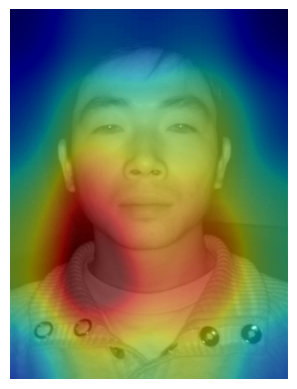

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image, ImageEnhance

# %% Step 5: Grad-CAM for Explainability
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.target_layer.register_forward_hook(self.save_features)
        self.target_layer.register_backward_hook(self.save_gradients)

    def save_features(self, module, input, output):
        self.features = output

    def save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def __call__(self, input_tensor, class_idx=None):
        self.model.eval()
        input_tensor = input_tensor.to(device)

        # Forward pass
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = torch.argmax(output)

        # Backward pass
        self.model.zero_grad()
        output[0, class_idx].backward()

        # Pool gradients and generate heatmap
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        for i in range(self.features.size(1)):
            self.features[0, i, :, :] *= pooled_gradients[i]
        heatmap = torch.mean(self.features, dim=1).squeeze()
        heatmap = F.relu(heatmap)
        heatmap /= torch.max(heatmap)
        return heatmap.cpu().detach().numpy()

# Preprocess an image for Grad-CAM
def preprocess_image(image_path):
    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ])
    image = Image.open(image_path)
    input_tensor = transform(image).unsqueeze(0)
    return input_tensor, image

# Overlay Grad-CAM heatmap
def overlay_heatmap(img, heatmap):
    heatmap = np.uint8(255 * heatmap)
    heatmap = Image.fromarray(heatmap).resize((img.width, img.height), Image.Resampling.LANCZOS)
    heatmap = np.array(heatmap)

    plt.imshow(img, cmap='gray')
    plt.imshow(heatmap, cmap='jet', alpha=0.5)
    plt.axis('off')
    plt.show()

# Generate Grad-CAM heatmap
def generate_gradcam(image_path):
    input_tensor, original_image = preprocess_image(image_path)
    grad_cam = GradCAM(model, model.backbone.layer4[-1])
    heatmap = grad_cam(input_tensor)
    overlay_heatmap(original_image, heatmap)

# Test Grad-CAM
test_image_path = "combined_dataset\\00001\\001.bmp"  # Replace with a test image path
generate_gradcam(test_image_path)

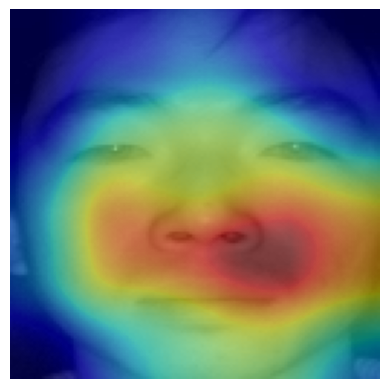

In [ ]:
# Test Grad-CAM
test_image_path = "cropped_faces_dataset/00001/001.bmp"  # Replace with a test image path
generate_gradcam(test_image_path)

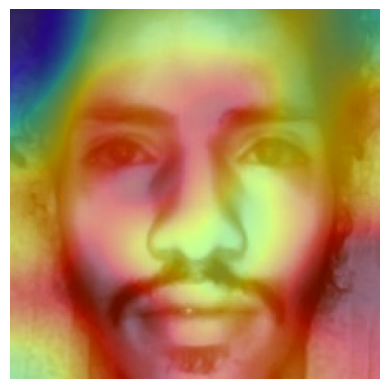

In [ ]:
# Test Grad-CAM
test_image_path = "cropped_dataset_HE_LAMPHQ\\FP0001\\NIR_FP0001_1_DOWN_a.jpg"  # Replace with a test image path
generate_gradcam(test_image_path)

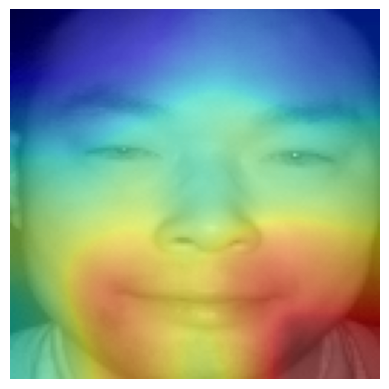

In [ ]:
# Preprocess the input image
image_path = "cropped_faces_dataset\\00050\\001.bmp"  # Path to the NIR image
generate_gradcam(image_path)

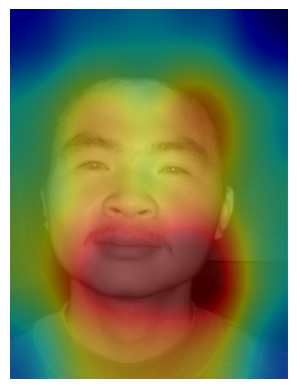

In [ ]:
# Preprocess the input image
image_path = "combined_dataset\\00014\\002.bmp"  # Path to the NIR image
generate_gradcam(image_path)

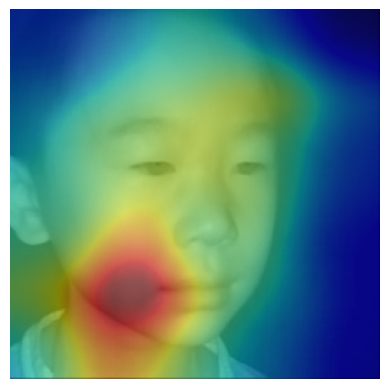

In [ ]:
# Preprocess the input image
image_path = "LAMPHQ\\P0343\\NIR_P0343_1_DOWN_e.jpg"  # Path to the NIR image
generate_gradcam(image_path)

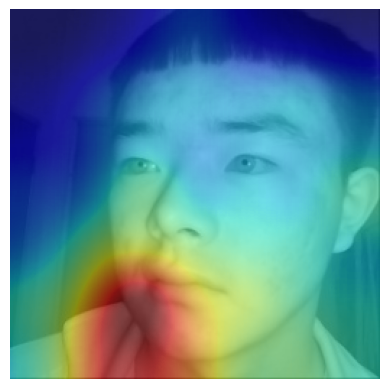

In [ ]:
# Preprocess the input image
image_path = "LAMPHQ\\P0573\\NIR_P0573_1_DOWN_f.jpg"  # Path to the NIR image
generate_gradcam(image_path)

In [ ]:
# Preprocess the input image
image_path = "combined_dataset\\00014\\002.bmp"  # Path to the NIR image
generate_gradcam(image_path)